In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
dz = gpd.read_file("data/DZ2021.shp")

In [3]:
dz.head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39..."
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39..."
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39..."
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39..."
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39..."


In [4]:
pop = pd.read_excel("data/census-2021-ms-a01.xlsx")

In [5]:
pop.head()

,Unnamed: 0,Unnamed: 1
0,National Statistics Theme:,Census 2021
1,Data subset:,Demography
2,Dataset title:,Usual resident population MS-A01
3,Coverage:,"Data Zone, Super Data Zone, Settlement, Ward, ..."
4,Source:,NISRA


In [6]:
pop = pd.read_excel(
    "data/census-2021-ms-a01.xlsx",
    sheet_name="DZ",
    skiprows=5
)

pop.head()

,Geography,Geography Code,All usual residents,Access census area explorer
0,Dunsilly_A1,N20000001,738,Dunsilly_A1 DZ profile
1,Dunsilly_B1,N20000002,331,Dunsilly_B1 DZ profile
2,Dunsilly_A2,N20000003,365,Dunsilly_A2 DZ profile
3,Dunsilly_A3,N20000004,663,Dunsilly_A3 DZ profile
4,Dunsilly_B2,N20000005,676,Dunsilly_B2 DZ profile


In [7]:
dz.columns

Index(['DZ2021_cd', 'DZ2021_nm', 'SDZ2021_cd', 'SDZ2021_nm', 'DEA2014_cd',
       'DEA2014_nm', 'LGD2014_cd', 'LGD2014_nm', 'Area_ha', 'Perim_km',
       'geometry'],
      dtype='str')

In [8]:
pop.columns

Index(['Geography', 'Geography Code', 'All usual residents',
       'Access census area explorer'],
      dtype='str')

In [9]:
dz = dz.merge(
    pop,
    left_on="DZ2021_cd",
    right_on="Geography Code"
)

In [10]:
dz.head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,Geography,Geography Code,All usual residents,Access census area explorer
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39...",Dunsilly_A1,N20000001,738,Dunsilly_A1 DZ profile
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39...",Dunsilly_B1,N20000002,331,Dunsilly_B1 DZ profile
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39...",Dunsilly_A2,N20000003,365,Dunsilly_A2 DZ profile
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39...",Dunsilly_A3,N20000004,663,Dunsilly_A3 DZ profile
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39...",Dunsilly_B2,N20000005,676,Dunsilly_B2 DZ profile


<Axes: >

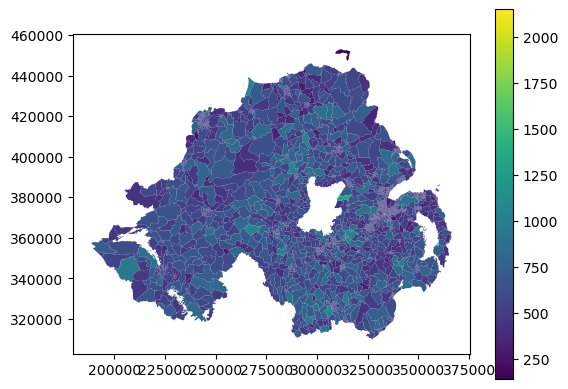

In [11]:
dz.plot(column="All usual residents", legend=True)

In [12]:
import osmnx as ox

In [13]:
# Reproject to latitude/longitude for OSM queries
dz_wgs84 = dz.to_crs("EPSG:4326")

# Check bounds in lat/lon
bbox = dz_wgs84.total_bounds

In [14]:
# Download hospital locations from OpenStreetMap using WGS84 bounds
hospitals = ox.features_from_bbox(
    bbox,
    tags={"amenity": "hospital"}
)

hospitals.head()

geometry  \
element  id                                                               
node     1376200677                           POINT (-7.28047 55.01356)   
         1376200841                           POINT (-7.28268 55.01539)   
         2545693040                           POINT (-7.48323 54.83127)   
         13196719821                             POINT (-5.9395 54.608)   
relation 5342502      POLYGON ((-6.40968 54.43304, -6.41098 54.43286...   

                       amenity healthcare                        name  \
element  id                                                             
node     1376200677   hospital   hospital          Waterside Hospital   
         1376200841   hospital   hospital                    Lakeview   
         2545693040   hospital   hospital  Lifford Community Hospital   
         13196719821  hospital   hospital              Macular Clinic   
relation 5342502      hospital   hospital     Craigavon Area Hospital   

                     emergency  addr:city addr:housenumber addr:postcode  \
element  id                                                                
node     1376200677         no        NaN              NaN           NaN   
         1376200841         no        NaN              NaN           NaN   
         2545693040        NaN        NaN              NaN           NaN   
         13196719821       NaN        NaN              NaN           NaN   
relation 5342502           yes  Portadown               68      BT63 5QQ   

                      addr:street description  ... building wheelchair  \
element  id                                    ...                       
node     1376200677           NaN         NaN  ...      NaN        NaN   
         1376200841           NaN         NaN  ...      NaN        NaN   
         2545693040           NaN         NaN  ...      NaN        NaN   
         13196719821          NaN         NaN  ...      NaN        NaN   
relation 5342502      Lurgan Road         NaN  ...      NaN        NaN   

                     source:geometry check_date contact:website          type  \
element  id                                                                     
node     1376200677              NaN        NaN             NaN           NaN   
         1376200841              NaN        NaN             NaN           NaN   
         2545693040              NaN        NaN             NaN           NaN   
         13196719821             NaN        NaN             NaN           NaN   
relation 5342502                 NaN        NaN             NaN  multipolygon   

                     HSE_code HSE_hgid HSE_hgroup HSE_region  
element  id                                                   
node     1376200677       NaN      NaN        NaN        NaN  
         1376200841       NaN      NaN        NaN        NaN  
         2545693040       NaN      NaN        NaN        NaN  
         13196719821      NaN      NaN        NaN        NaN  
relation 5342502          NaN      NaN        NaN        NaN  

[5 rows x 42 columns]

In [15]:
# Check hospital geometry types
hospitals.geometry.type.value_counts()

Polygon    58
Point       4
Name: count, dtype: int64

In [16]:
# Keep all relevant hospital geometries
hospitals = hospitals[hospitals.geometry.type.isin(["Point", "Polygon", "MultiPolygon"])]

In [17]:
# Create a representative point for each hospital
hospitals["hospital_point"] = hospitals.geometry.representative_point()

# Use these points as geometry
hospitals = hospitals.set_geometry("hospital_point")

In [18]:
# Match coordinate system with Data Zones
hospitals = hospitals.to_crs(dz.crs)

In [19]:
# Keep only hospitals located within the Northern Ireland study area.
# 'intersects' is used instead of 'within' to avoid excluding boundary cases.
hospitals = hospitals[hospitals.intersects(dz.union_all())]

In [20]:
# Check number of hospitals after cleaning
len(hospitals)

41

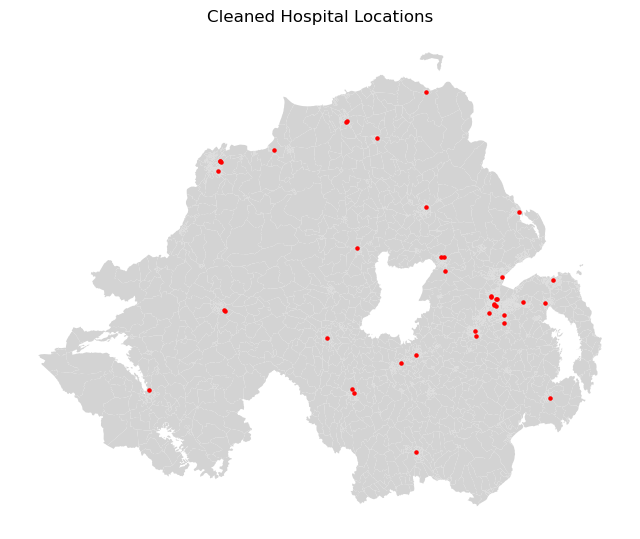

In [21]:
import matplotlib.pyplot as plt

# Plot Data Zones as background map
ax = dz.plot(color="lightgrey", figsize=(8,8))

# Overlay hospital locations to visually check they are correctly positioned
hospitals.plot(ax=ax, color="red", markersize=5)

# Add title for map clarity
ax.set_title("Cleaned Hospital Locations")

# Remove axis for cleaner map display
ax.axis("off")

plt.show()

In [24]:
# Check Data Zone and hospital coordinate reference systems are the same
print(dz.crs)
print(hospitals.crs)

EPSG:29902
EPSG:29902


In [26]:
# Create a representative point for each Data Zone polygon
dz["zone_point"] = dz.geometry.representative_point()

# Create a copy using these points
dz_points = dz.copy()
dz_points = dz_points.set_geometry("zone_point")

# Calculate distance to nearest hospital
distances = []

for point in dz_points.geometry:
    nearest_distance = hospitals.distance(point).min()
    distances.append(nearest_distance)

dz["nearest_hospital_m"] = distances

In [27]:
dz["nearest_hospital_m"].head()

0     6130.544270
1    10696.733917
2    10397.314164
3     7133.134185
4     7427.504274
Name: nearest_hospital_m, dtype: float64

In [29]:
# Check that a distance has been calculated for every Data Zone (outputs should be the same)
print(len(dz))
print(len(distances))

3780
3780


In [31]:
# Verify no missing values in calculated hospital distances (output should be 0)
dz["nearest_hospital_m"].isna().sum()

np.int64(0)

In [33]:
# Convert distance from metres to kilometres
dz["nearest_hospital_km"] = dz["nearest_hospital_m"] / 1000

# Preview the first few values of distance to nearest hospital (in km)
# This confirms the conversion from metres worked correctly
dz["nearest_hospital_km"].head()

0     6.130544
1    10.696734
2    10.397314
3     7.133134
4     7.427504
Name: nearest_hospital_km, dtype: float64

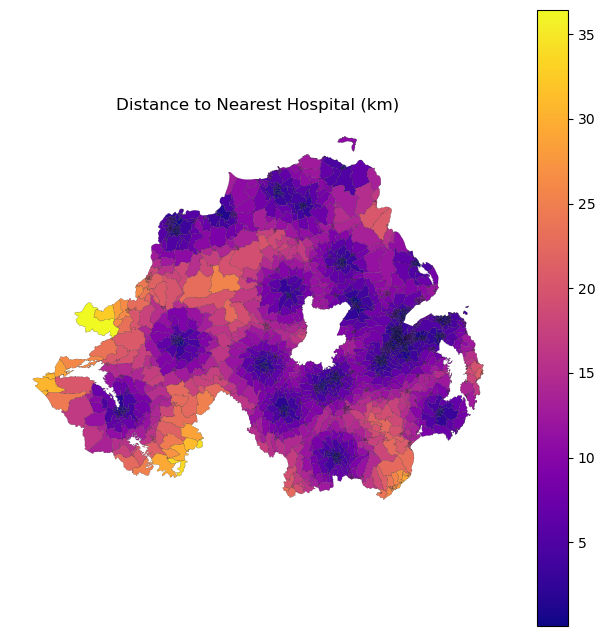

In [34]:
import matplotlib.pyplot as plt

# Map distance to nearest hospital across Northern Ireland
ax = dz.plot(
    column="nearest_hospital_km",
    cmap="plasma",
    legend=True,
    figsize=(8,8),
    edgecolor="black",
    linewidth=0.1
)

# Add title
ax.set_title("Distance to Nearest Hospital (km)")

# Remove axes for cleaner display
ax.axis("off")

plt.show()

In [36]:
# Estimate number of people living far from hospitals
# Areas more than 20 km from a hospital are considered to have poor access
dz["population_far"] = dz["All usual residents"] * (dz["nearest_hospital_km"] > 20)

# Preview results to confirm calculation worked correctly
# Zones >20 km should show full population, others should show 0
dz[["DZ2021_nm", "All usual residents", "nearest_hospital_km", "population_far"]].head()

,DZ2021_nm,All usual residents,nearest_hospital_km,population_far
0,Dunsilly_A1,738,6.130544,0
1,Dunsilly_B1,331,10.696734,0
2,Dunsilly_A2,365,10.397314,0
3,Dunsilly_A3,663,7.133134,0
4,Dunsilly_B2,676,7.427504,0


In [40]:
# Check that some Data Zones are classified as having poor access (>20 km)
dz[dz["nearest_hospital_km"] > 20].head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,Geography,Geography Code,All usual residents,Access census area explorer,zone_point,nearest_hospital_m,nearest_hospital_km,population_far
592,N20000593,Lagan_River_N5,N21000135,Lagan_River_N,N10000205,Lagan River,N09000002,"Armagh City, Banbridge and Craigavon",1035.07,15.95,"POLYGON ((323510.184 342629.969, 323514.066 34...",Lagan_River_N5,N20000593,609,Lagan_River_N5 DZ profile,POINT (322431.019 342321.878),21251.612111,21.251612,609
649,N20000650,Banbridge_P1,N21000148,Banbridge_P,N10000202,Banbridge,N09000002,"Armagh City, Banbridge and Craigavon",505.06,15.14,"POLYGON ((325573.116 340102.254, 325574.654 34...",Banbridge_P1,N20000650,391,Banbridge_P1 DZ profile,POINT (324904.035 339688.685),21400.527783,21.400528,391
1545,N20001546,Bann_G5,N21000356,Bann_G,N10000402,Bann,N09000004,Causeway Coast and Glens,1768.24,20.03,"POLYGON ((281051.721 411809.061, 281226.275 41...",Bann_G5,N20001546,337,Bann_G5 DZ profile,POINT (279730.5 411293.124),20034.784561,20.034785,337
1681,N20001682,The_Glens_G3,N21000385,The_Glens_G,N10000407,The Glens,N09000004,Causeway Coast and Glens,14.59,1.72,"POLYGON ((323957.993 425518.53, 323962 425520....",The_Glens_G3,N20001682,375,The_Glens_G3 DZ profile,POINT (324070.888 425405.688),20123.404840,20.123405,375
1683,N20001684,The_Glens_G4,N21000385,The_Glens_G,N10000407,The Glens,N09000004,Causeway Coast and Glens,5445.69,39.14,"POLYGON ((326095.288 422398.929, 326094.99 422...",The_Glens_G4,N20001684,724,The_Glens_G4 DZ profile,POINT (321619.541 421542.873),20241.042956,20.241043,724


In [41]:
# Verify population_far values for these zones
# For zones >20 km, population_far should equal total population (not 0)
dz[dz["nearest_hospital_km"] > 20][
    ["DZ2021_nm", "nearest_hospital_km", "population_far"]
].head()

,DZ2021_nm,nearest_hospital_km,population_far
592,Lagan_River_N5,21.251612,609
649,Banbridge_P1,21.400528,391
1545,Bann_G5,20.034785,337
1681,The_Glens_G3,20.123405,375
1683,The_Glens_G4,20.241043,724


In [43]:
# Calculate total population living more than 20 km from a hospital (indicator of poor accessibility)
dz["population_far"].sum()

np.int64(77299)

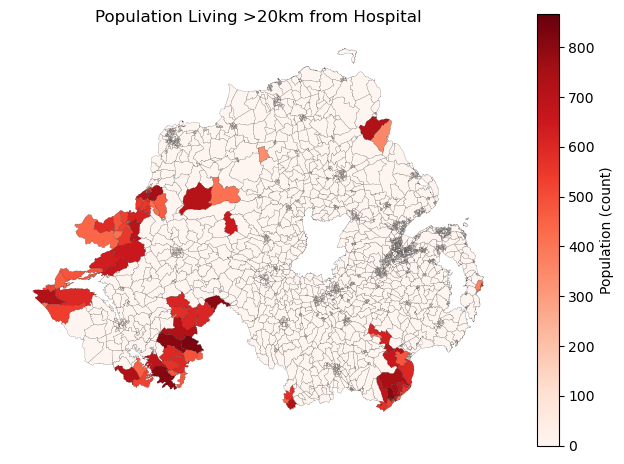

In [49]:
import matplotlib.pyplot as plt

# Map population living more than 20 km from a hospital
# This highlights areas where large numbers of people have poor access
ax = dz.plot(
    column="population_far",
    cmap="Reds",
    legend=True,
    figsize=(8,8),
    edgecolor="black",
    linewidth=0.1,
    legend_kwds={
        "label": "Population (count)",
        "orientation": "vertical",
        "shrink": 0.7
    }
)

# Add title
ax.set_title("Population Living >20km from Hospital")

# Remove axes for cleaner display
ax.axis("off")

plt.show()